In [71]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import scipy as sc
from scipy.constants import G
from IPython.display import clear_output
import time

In [72]:
def newton_force(coords1:np.ndarray, mass1:float, coords2:np.ndarray, mass2:float) -> float:
    r = np.linalg.norm(coords1 - coords2)
    F = G*(mass1*mass2)/(r**2)
    return F


In [73]:
def initial_plot(coords:list) -> None:
    fig = plt.figure()
    ax = fig.add_subplot(projection="3d")
    ax.set(xlim3d=(-1.5e11, 1.5e11), xlabel='X')
    ax.set(ylim3d=(-1.5e11, 1.5e11), ylabel='Y')
    ax.set(zlim3d=(-1.5e11, 1.5e11), zlabel='Z')
    for t in coords:
        ax.scatter(t[0], t[1], t[2])
    plt.show()


In [74]:
def leapfrog_integration(coords:list, velocities:list, masses:list, dt) -> tuple:
    # Unpack values    
    x1 = coords[0]
    x2 = coords[1]

    # Calculate unit vectors in the direction of the force
    r1 = (x2 - x1) / np.linalg.norm(x2 - x1)
    r2 = -r1

    m1 = masses[0]
    m2 = masses[1]

    v1 = velocities[0]
    v2 = velocities[1]

    # Calculate the gravitational force magnitude
    F = newton_force(x1, m1, x2, m2)

    # Calculate acceleration magnitudes
    a1 = F / m1
    a2 = F / m2

    # Update velocities using the acceleration (note the dt factor)
    v1_inter = v1 + 0.5 * a1 * dt * r1
    v2_inter = v2 + 0.5 * a2 * dt * r2

    # Update positions using current velocities
    x1_new = x1 + v1_inter * dt
    x2_new = x2 + v2_inter * dt

    # Calculating end velocities
    F_new = newton_force(x1_new, m1, x2_new, m2)

    r1_new = (x2_new - x1_new) / np.linalg.norm(x2_new - x1_new)
    r2_new = -r1_new

    a1_new = F_new / m1
    a2_new = F_new / m2

    v1_new = v1_inter + 0.5 * a1_new * dt * r1_new
    v2_new = v2_inter + 0.5 * a2_new * dt * r2_new

    return [x1_new, x2_new], [v1_new, v2_new]


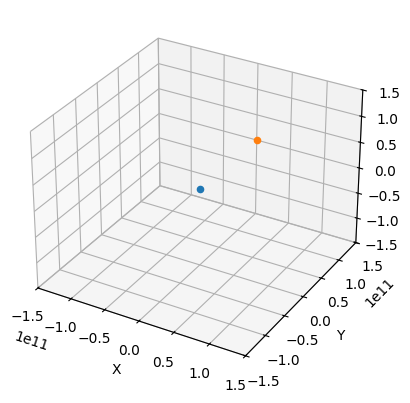

In [75]:
coords = [np.array([0, 0, 0], dtype=float), np.array([0, 1.5e11, 0], dtype=float)]
velocities = [np.array([0, 0, 0], dtype=float), np.array([0, 0, 30000], dtype=float)]
masses = [1.989e30, 5.972e24]
dt = 1000
initial_plot(coords)

In [76]:
# while True:
#     coords, velocities = leapfrog_integration(coords, velocities, masses, 10000)
#     initial_plot(coords)
#     clear_output(wait=True)

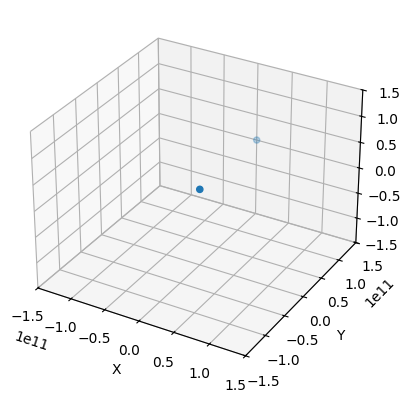

In [77]:
fig = plt.figure()
ax = fig.add_subplot(projection="3d")
ax.set(xlim3d=(-1.5e11, 1.5e11), xlabel='X')
ax.set(ylim3d=(-1.5e11, 1.5e11), ylabel='Y')
ax.set(zlim3d=(-1.5e11, 1.5e11), zlabel='Z')
coords_T = np.array(coords).T
scat = ax.scatter(coords_T[0], coords_T[1], coords_T[2])
plt.show()

In [78]:
def update(frame, masses:list, dt:float):
    global coords, velocities
    coords, velocities = leapfrog_integration(coords, velocities, masses, dt)
    coords_T = np.array(coords).T
    scat.set_offsets(coords_T[0], coords_T[1], coords_T[2])

In [79]:
ani= animation.FuncAnimation(fig=fig, func=update, frames=None, interval=1, fargs=(masses, dt), cache_frame_data=False)
plt.show()

/Users/jonas/coding/python/gravity/myenv/lib/python3.12/site-packages/matplotlib/animation.py:908: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(
